In [1]:
import wfdb
import os

os.makedirs('data/bidmc', exist_ok=True)
wfdb.dl_database('bidmc', 'data/bidmc')
print(" Download complete")

Generating record list for: bidmc01
Generating record list for: bidmc02
Generating record list for: bidmc03
Generating record list for: bidmc04
Generating record list for: bidmc05
Generating record list for: bidmc06
Generating record list for: bidmc07
Generating record list for: bidmc08
Generating record list for: bidmc09
Generating record list for: bidmc10
Generating record list for: bidmc11
Generating record list for: bidmc12
Generating record list for: bidmc13
Generating record list for: bidmc14
Generating record list for: bidmc15
Generating record list for: bidmc16
Generating record list for: bidmc17
Generating record list for: bidmc18
Generating record list for: bidmc19
Generating record list for: bidmc20
Generating record list for: bidmc21
Generating record list for: bidmc22
Generating record list for: bidmc23
Generating record list for: bidmc24
Generating record list for: bidmc25
Generating record list for: bidmc26
Generating record list for: bidmc27
Generating record list for: 

In [2]:
files = [f for f in os.listdir('data/bidmc') if f.endswith('.hea')]
print(f"Records downloaded: {len(files)}/53")
print("Sample files:", sorted(files)[:5])

Records downloaded: 53/53
Sample files: ['bidmc01.hea', 'bidmc02.hea', 'bidmc03.hea', 'bidmc04.hea', 'bidmc05.hea']


In [3]:
record = wfdb.rdrecord('data/bidmc/bidmc01')
print("Signal names :", record.sig_name)
print("Sampling rate:", record.fs, "Hz")
print("Signal shape :", record.p_signal.shape)
print("Duration (min):", round(record.p_signal.shape[0] / record.fs / 60, 1))

Signal names : ['RESP,', 'PLETH,', 'V,', 'AVR,', 'II,']
Sampling rate: 125 Hz
Signal shape : (60001, 5)
Duration (min): 8.0


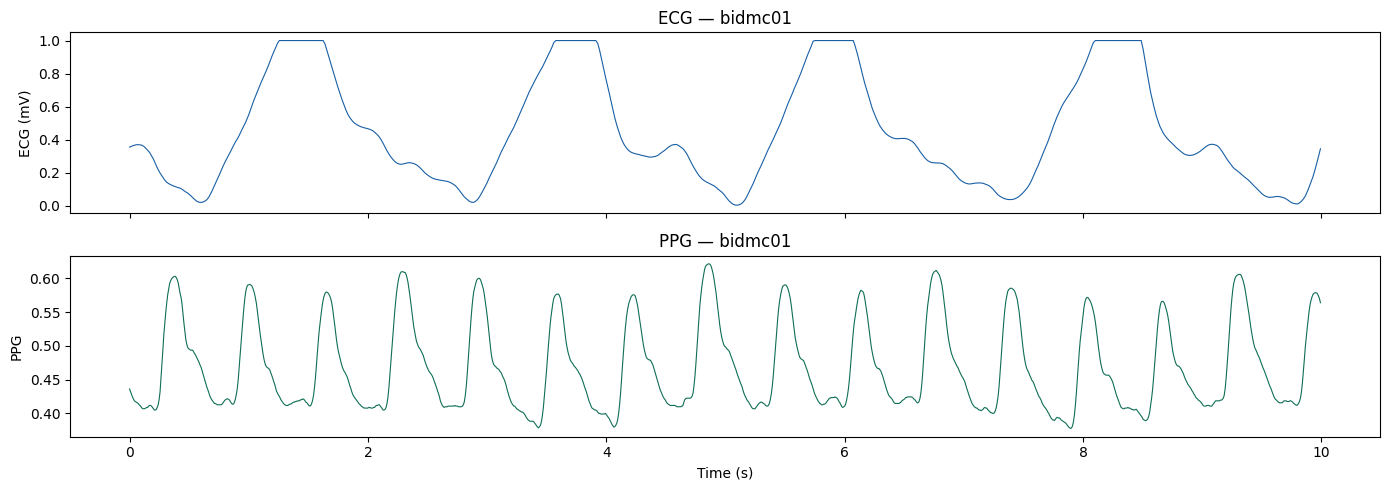

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fs = 125
samples = 10 * fs  # 10 seconds
ecg = record.p_signal[:samples, 0]
ppg = record.p_signal[:samples, 1]
t   = np.arange(samples) / fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t, ecg, color='#185FA5', linewidth=0.8)
ax1.set_ylabel('ECG (mV)'); ax1.set_title('ECG — bidmc01')
ax2.plot(t, ppg, color='#0F6E56', linewidth=0.8)
ax2.set_ylabel('PPG'); ax2.set_xlabel('Time (s)'); ax2.set_title('PPG — bidmc01')
plt.tight_layout()
plt.savefig('data/bidmc_sample_plot.png', dpi=150)
plt.show()